## Phase 1: Domain Adaptation via LoRA (Low-Rank Adaptation)



In this phase, we induce a stylistic shift in the base model by fine-tuning it on a journalistic dataset. Instead of performing a full-parameter update (which is computationally expensive and prone to catastrophic forgetting), we utilize **Parameter-Efficient Fine-Tuning (PEFT)** via LoRA.

Here is a breakdown of the architectural setup:

* **Base Model Initialization:** We load the standard `gpt2` model and configure the tokenizer's padding token to handle variable-length sequences during training.
* **LoRA Configuration:** We inject trainable low-rank decomposition matrices ($r=8$, $\alpha=32$) specifically into the attention (`c_attn`) and projection (`c_proj`) modules of the transformer blocks. This freezes the pre-trained weights and drastically reduces the number of trainable parameters.
* **Dataset Injection:** We utilize a subset of 500 articles from the `cnn_dailymail` dataset. This targeted dataset acts as the stylistic anchor, teaching the model formal news reporting structures.
* **Supervised Fine-Tuning (SFT):** We configure the `SFTTrainer` with optimized hyperparameters, utilizing mixed-precision (`fp16=True`) for memory efficiency. Finally, we train the model and save only the lightweight adapter weights for future spectral comparison.

In [2]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_name)

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["c_attn", "c_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
dataset = load_dataset("abisee/cnn_dailymail", "3.0.0", split="train[:500]")

sft_config = SFTConfig(
    output_dir="./gpt2-lora-news",
    dataset_text_field="article",
    per_device_train_batch_size=4,
    num_train_epochs=1,
    logging_steps=10,
    learning_rate=2e-4,
    fp16=True,
    bf16=False
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    args=sft_config,
)

trainer.train()
model.save_pretrained("./fine_tuned_gpt2_weights")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1194 > 1024). Running this sequence through the model will result in indexing errors


Truncating train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

c:\Users\FARIBA\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,3.157884
20,3.193802
30,3.092852
40,3.080341
50,3.107155
60,3.038438
70,3.076722
80,3.086854
90,3.062903
100,3.044300


## Phase 2: Behavioral Shift Evaluation (Inference Comparison)

Before delving into the mechanistic changes within the weight matrices, we must empirically validate the success of the adaptation process. This step demonstrates the macroscopic "behavioral shift" of the model.

We provide an identical starting prompt (`"The president announced today that"`) to both the raw, pre-trained base model and our newly adapted LoRA model. 

* **Base GPT-2:** Generates text based on its original, unstructured internet training distribution. Its output typically defaults to generic, informal text and is highly prone to repetitive generation loops.
* **LoRA Tuned GPT-2:** Leverages the newly injected adapter weights. The output is expected to strictly adhere to the linguistic distribution of the CNN dataset, exhibiting a structured, formal journalistic tone (e.g., precise date formatting, official PR phrasing).

By comparing these outputs side-by-side, we practically confirm that the lightweight rank-decomposition matrices successfully steered the model's generative distribution before we analyze the underlying mathematics.

In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
base_model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

prompt = "The president announced today that"
inputs = tokenizer(prompt, return_tensors="pt").to(device)

print("--- Before Fine-Tuning (Base GPT-2) ---")
base_outputs = base_model.generate(**inputs, max_new_tokens=40, pad_token_id=tokenizer.eos_token_id)
print(tokenizer.decode(base_outputs[0], skip_special_tokens=True))

print("\n" + "="*50 + "\n")

tuned_model = PeftModel.from_pretrained(base_model, "./fine_tuned_gpt2_weights").to(device)

print("--- After Fine-Tuning (LoRA CNN News) ---")
tuned_outputs = tuned_model.generate(**inputs, max_new_tokens=40, pad_token_id=tokenizer.eos_token_id)
print(tokenizer.decode(tuned_outputs[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

--- Before Fine-Tuning (Base GPT-2) ---
The president announced today that he will be leaving the White House in January.

"I'm going to be leaving the White House in January," Trump said. "I'm going to be leaving the country in January."


--- After Fine-Tuning (LoRA CNN News) ---
The president announced today that he will be leaving the White House on Friday, July 1, after a three-year term.

"I am deeply saddened by the loss of my friend and colleague, and I am deeply


## Phase 3: Zero-Shot Latent Concept Extraction via Spectral Analysis



With the behavioral shift confirmed, we transition to **Mechanistic Interpretability**. The goal here is to analyze the internal representations of the models *without* relying on input prompts or forward passes (Zero-Shot Analysis). We achieve this by applying Singular Value Decomposition (SVD) directly to the weight matrices.

### Methodology:
1. **Target Layer Isolation:** We extract the weight matrix from the final MLP projection layer (`c_proj` in Layer 11), as deeper layers in transformer architectures are known to encode high-level semantic abstractions rather than basic syntax.
2. **Model Merging:** For the fine-tuned model, we merge the LoRA adapter weights back into the base model weights ($W_{tuned} = W_{base} + \Delta W$) using `merge_and_unload()` to get the complete, updated mathematical representation.
3. **SVD Application:** We decompose the matrices to extract the top-$k$ principal singular vectors ($V$), which represent the directions of maximum variance (the foundational semantic concepts learned by the model).
4. **Vocabulary Projection:** By projecting these principal vectors onto the model's unembedding matrix (`lm_head`), we map the latent dimensions back into human-readable tokens.

### The Objective:
By comparing the top singular vectors of $W_{base}$ and $W_{tuned}$, we test the hypothesis of **Catastrophic Forgetting**. Because LoRA updates the model via a low-rank bottleneck, the highest-variance directions (the core linguistic foundation) should remain structurally identical, proving that the model preserves its fundamental knowledge while absorbing the new journalistic style in lower-variance subspaces.

In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
unbedding_matrix = AutoModelForCausalLM.from_pretrained(model_name).lm_head.weight.data

base_model = AutoModelForCausalLM.from_pretrained(model_name)
w_base = base_model.transformer.h[-1].mlp.c_proj.weight.data.clone()

tuned_model = PeftModel.from_pretrained(base_model, "./fine_tuned_gpt2_weights")
merged_model = tuned_model.merge_and_unload()
w_tuned = merged_model.transformer.h[-1].mlp.c_proj.weight.data.clone()

def get_top_concepts(weight_matrix, k=5):
    U, S, V = torch.svd(weight_matrix.float())
    top_directions = V[:, :k]
    projections = torch.matmul(top_directions.T, unbedding_matrix.T)
    
    concepts = []
    for i in range(k):
        indices = torch.topk(projections[i], 8).indices
        words = tokenizer.convert_ids_to_tokens(indices)
        clean_words = [w.replace('Ġ', '') for w in words]
        concepts.append(clean_words)
    return concepts

print("--- Latent Concepts: Base GPT-2 (Layer 11) ---")
base_concepts = get_top_concepts(w_base)
for i, c in enumerate(base_concepts):
    print(f"Vector {i+1}: {c}")

print("\n" + "="*50 + "\n")

print("--- Latent Concepts: LoRA Tuned (Layer 11) ---")
tuned_concepts = get_top_concepts(w_tuned)
for i, c in enumerate(tuned_concepts):
    print(f"Vector {i+1}: {c}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

--- Latent Concepts: Base GPT-2 (Layer 11) ---
Vector 1: ['the', ',', '-', 'and', 'a', '.', 'in', '"']
Vector 2: ['(', 'and', 's', 'or', '/', 'if', 'a', '3']
Vector 3: ['Buyable', 'acknow', 'misunder', 'BuyableInstoreAndOnline', 'Azerb', 'indo', 'Vaugh', 'Yanuk']
Vector 4: ['-', 'cloud', 'pload', 'mpeg', 'anamo', 'hy', 'grab', 'ãĤ¿']
Vector 5: ['On', 'on', 'on', 'On', 'ON', 'upon', 'upon', 'onto']


--- Latent Concepts: LoRA Tuned (Layer 11) ---
Vector 1: ['the', ',', '-', 'and', 'a', '.', 'in', '"']
Vector 2: ['(', 'and', 's', 'or', '/', 'if', 'a', '3']
Vector 3: ['Buyable', 'acknow', 'misunder', 'BuyableInstoreAndOnline', 'Azerb', 'indo', 'Vaugh', 'Yanuk']
Vector 4: ['-', 'cloud', 'pload', 'mpeg', 'anamo', 'hy', 'grab', 'ãĤ¿']
Vector 5: ['On', 'on', 'on', 'On', 'ON', 'upon', 'upon', 'onto']


## Phase 4: Statistical Distribution of Weight Updates ($\Delta W$)



To further prove the efficiency and safety of the LoRA fine-tuning process, we visualize the exact mathematical changes applied to the model's parameters. We calculate the delta matrix ($\Delta W = W_{tuned} - W_{base}$) for the selected projection layer and plot the statistical distribution of its values.

### Key Observations:
* **Zero-Centered Density:** By plotting the frequency of weight changes on a logarithmic scale, we observe that the overwhelming majority of updates are tightly clustered exactly around zero (indicated by the red dashed line).
* **Low-Rank Bottleneck Validation:** Because LoRA constrains updates to a low-rank decomposition ($r=8$), it physically cannot alter the entire high-dimensional weight space. The sharp, bell-shaped distribution confirms that the core mathematical structure of the base model remains largely untouched.
* **Empirical Proof Against Catastrophic Forgetting:** The minimal magnitude of the updates ($\Delta W$) serves as mathematical evidence that the model has successfully absorbed the new journalistic style *without* aggressively overwriting its fundamental, pre-trained knowledge base.

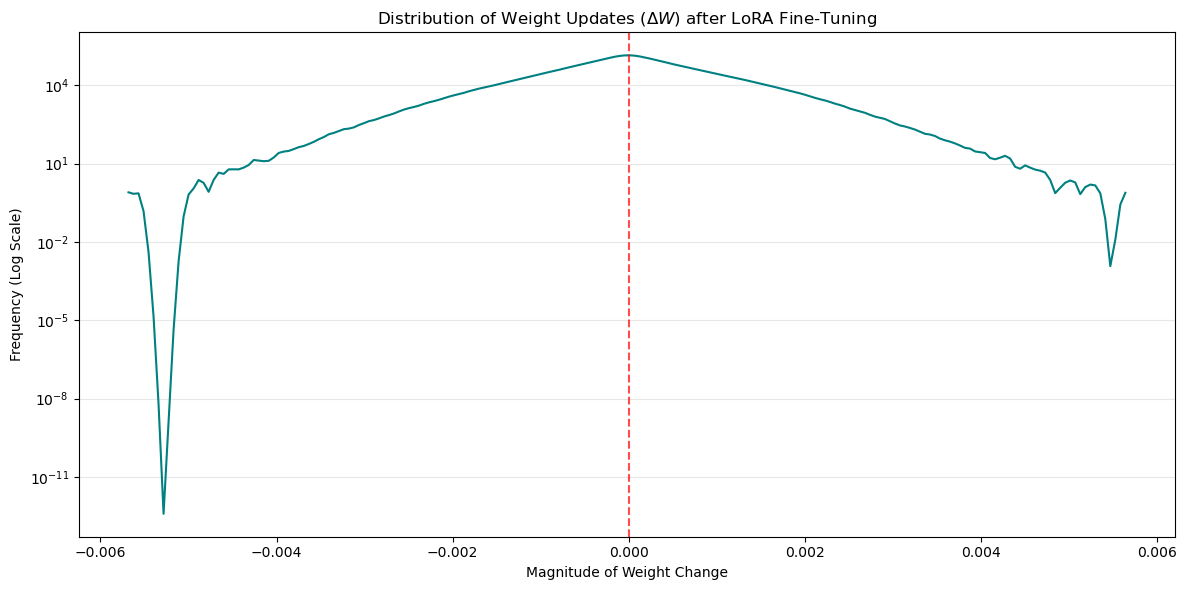

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

w_delta = w_tuned - w_base
delta_values = w_delta.flatten().numpy()

plt.figure(figsize=(12, 6))
sns.histplot(delta_values, bins=150, color='teal', kde=True, log_scale=(False, True))

plt.title("Distribution of Weight Updates ($\Delta W$) after LoRA Fine-Tuning")
plt.xlabel("Magnitude of Weight Change")
plt.ylabel("Frequency (Log Scale)")
plt.axvline(0, color='red', linestyle='dashed', linewidth=1.5, alpha=0.7)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Phase 5: Decoding Semantic Emergence via Logit Lens



In this final phase, we employ the **Logit Lens** technique to peer into the "subconscious" of the model. Standard inference only reveals the final output token, but the Logit Lens allows us to project the intermediate hidden states of every single transformer layer directly into the vocabulary space. This reveals *where* and *how* the model forms its decisions.

### Technical Implementation:
* **Hidden State Extraction:** We execute a forward pass with `output_hidden_states=True` to capture the contextualized embeddings at every depth of the network (Layers 0 through 12).
* **LayerNorm Scaling:** A critical engineering step in this implementation is applying the model's final Layer Normalization (`ln_f`) to the intermediate states before projection. Without this scaling, raw intermediate states suffer from a distribution mismatch with the unembedding matrix, yielding noisy and uninterpretable logits.
* **Unembedding Projection:** We multiply the normalized hidden states by the language modeling head (`lm_head.weight.data`) to decode the top-$k$ latent token predictions at each individual layer.

### Analytical Value & Observation:
By tracking the prompt `"The color of the sky is"`, this technique visualizes the model's internal cognitive trajectory. We can observe the exact layer transition where the model stops processing basic syntax (initially predicting generic grammatical tokens like `not`, `also`, or `the`) and successfully converges on the definitive semantic concept (`blue` or `color`). This layer-by-layer mapping provides profound, mechanistic insights into the hierarchical feature extraction of Large Language Models.

In [9]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, output_hidden_states=True)

unbedding_matrix = model.lm_head.weight.data
final_ln = model.transformer.ln_f 

prompt = "The color of the sky is"
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    hidden_states = outputs.hidden_states

print(f"Tracking with LayerNorm scaling for prompt: '{prompt}'\n")

for layer_idx, h in enumerate(hidden_states):
    h_last = h[0, -1, :]
    
    h_normalized = final_ln(h_last)
    
    logits = torch.matmul(unbedding_matrix, h_normalized)
    
    top_ids = torch.topk(logits, 3).indices
    top_words = [tokenizer.decode([idx]).strip() for idx in top_ids]
    
    print(f"Layer {layer_idx:02d}: {top_words}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Tracking with LayerNorm scaling for prompt: 'The color of the sky is'

Layer 00: ['destro', 'mathemat', 'arrang']
Layer 01: ['not', 'also', 'still']
Layer 02: ['now', 'not', 'also']
Layer 03: ['now', 'not', 'also']
Layer 04: ['now', 'not', 'also']
Layer 05: ['not', 'now', 'also']
Layer 06: ['not', 'also', 'now']
Layer 07: ['now', 'not', 'also']
Layer 08: ['now', 'also', 'not']
Layer 09: ['color', 'colored', 'always']
Layer 10: ['color', 'bright', 'colored']
Layer 11: ['blue', 'bright', 'red']
Layer 12: ['the', ',', 'a']
